# QMML Hackathon - Support Session Demo
## Stock 1 Walkthrough
# Scroll all the way down
This notebook walks through the full pipeline for Stock 1:
1. Load & explore the data
2. Train/validation split
3. Fit a Linear Regression baseline
4. Fit XGBoost
5. Compare with RMSE
6. Make final prediction on the test set
7. Think about how prediction → spread

Then it's your turn to apply this to stocks 2–9!


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install xgboost
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

Defaulting to user installation because normal site-packages is not writeable



## 2. Load & Explore the Data

Let's start by understanding what we're working with.

In [6]:
# Load stock 1 training data
df = pd.read_csv('stock_1_train.csv')
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Features: {df.shape[1] - 1}, Target: 1")
df.head()

Shape: (19999, 6)
Rows: 19999, Features: 5, Target: 1


,col_0,col_1,col_2,col_3,col_4,target
0,1.574674,0.170111,-0.045997,0.758763,0.185289,223.453581
1,-0.802095,-0.246373,1.640907,-0.141742,-0.163337,211.253687
2,0.216712,0.468679,-0.786830,-0.152416,0.293351,280.980886
3,0.864578,-0.343601,-1.563815,0.621198,1.124796,266.650511
4,1.465125,-0.861386,-0.950072,-0.218991,-0.597203,216.206945


### Quick sanity checks
- How are the features distributed?
- Any missing values?
- What range is the target in?

In [8]:
# Summary statistics
df.describe().round(2)

,col_0,col_1,col_2,col_3,col_4,target
count,19999.00,19999.00,19999.00,19999.00,19999.00,19999.00
mean,-0.01,-0.00,-0.00,0.00,-0.00,246.14
std,1.01,1.01,0.99,1.01,1.01,39.05
min,-3.89,-3.82,-4.39,-3.70,-4.26,80.00
25%,-0.68,-0.68,-0.67,-0.67,-0.68,219.84
50%,-0.02,-0.01,-0.00,-0.00,-0.01,246.11
75%,0.66,0.67,0.66,0.67,0.68,272.19
max,5.01,4.09,4.33,4.51,4.15,400.00


In [4]:
# Any missing values?
print(df.isnull().sum())

col_0     0
col_1     0
col_2     0
col_3     0
col_4     0
target    0
dtype: int64


In [5]:
# Which features correlate most with the target?
print(df.corr()['target'].sort_values(ascending=False))

target    1.000000
col_1     0.646885
col_4     0.000560
col_3    -0.002781
col_0    -0.385041
col_2    -0.642064
Name: target, dtype: float64


### Quick aside: the datasets are NOT all the same

In [37]:
# Check the shape of ALL 9 training sets
for i in range(1, 10):
    temp = pd.read_csv(stock_{i}_train.csv')
    print(f"Stock {i}: {temp.shape[0]:>6} rows, {temp.shape[1]-1:>2} features")

SyntaxError: unterminated string literal (detected at line 3) (328501172.py, line 3)

Some stocks have 29 rows. Others have 20,000. A complex model will overfit badly on the small ones. Keep this in mind!

## 3. Train/Validation Split

This is important. The test set has only 1 row and no target, meaning we can't evaluate on it.

We must split the training data to create our own validation set. 
This is how we know how good our model is **before** the competition.

In [39]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# 80/20 split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")

NameError: name 'df' is not defined

## 4. Linear Regression - The Baseline

Simple, fast, hard to overfit. Always start here.

In [18]:
# Fit Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on validation set
lr_preds = lr_model.predict(X_val)

# Calculate RMSE
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_preds))
print(f"Linear Regression RMSE: {lr_rmse:.2f}")

Linear Regression RMSE: 4.81


In [19]:
# What coefficients did LR learn?
for name, coef in zip(X.columns, lr_model.coef_):
    print(f"{name}: {coef:>8.2f}")
print(f"Intercept: {lr_model.intercept_:.2f}")

col_0:   -15.33
col_1:    25.22
col_2:   -25.37
col_3:     0.03
col_4:     0.10
Intercept: 245.95


## 5. XGBoost - Trying a different model

XGBoost can capture non-linear patterns and feature interactions that Linear Regression misses.

In [15]:
# Fit XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,   # number of trees
    max_depth=3,         # how complex each tree is
    learning_rate=0.1,   # how much each tree contributes
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict on validation set
xgb_preds = xgb_model.predict(X_val)

# Calculate RMSE
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))
print(f"XGBoost RMSE: {xgb_rmse:.2f}")

NameError: name 'X_train' is not defined

## 6. Compare Models

In [ ]:
print("=" * 40)
print("Model Comparison — Stock 1")
print("=" * 40)
print(f"Linear Regression RMSE: {lr_rmse:.2f}")
print(f"XGBoost RMSE:           {xgb_rmse:.2f}")
print()

if lr_rmse < xgb_rmse:
    print(">>> Linear Regression wins on this stock!")
    print("This suggests the relationship is mostly linear.")
    print("A fancier model isn't always better.")
else:
    print(">>> XGBoost wins on this stock!")
    print("There are non-linear patterns that LR can't capture.")

**Key takeaway:** More complex ≠ always better. Test both, use what works. This will vary across the 9 stocks!

## 7. Make Final Prediction on the Test Set

Now we retrain on ALL the training data (no holdout) and predict the single test row.

In [9]:
# Retrain on FULL training data
final_model = LinearRegression()  # using LR since it won on this stock
final_model.fit(X, y)

# Load the test set (just 1 row, no target)
test = pd.read_csv('hackathon_data/stock_1_test.csv')
print(f"Test set shape: {test.shape}")
print(test)

# Predict!
prediction = final_model.predict(test)[0]
print(f"\nPredicted true value for Stock 1: £{prediction:.2f}")

NameError: name 'X' is not defined


## 8. From Prediction to Spread

Your prediction + your RMSE = your spread.

RMSE tells you how uncertain your model is. Use it to set sensible bounds.

In [14]:
print(f"Prediction: £{prediction:.2f}")
print(f"Model RMSE: £{lr_rmse:.2f}")
print()
print("Possible spread strategies:")
print(f"  Conservative (±2 RMSE): [{prediction - 2*lr_rmse:.2f}, {prediction + 2*lr_rmse:.2f}]  Spread = £{4*lr_rmse:.2f}")
print(f"  Moderate     (±1 RMSE): [{prediction - lr_rmse:.2f}, {prediction + lr_rmse:.2f}]  Spread = £{2*lr_rmse:.2f}")
print(f"  Aggressive (±0.5 RMSE): [{prediction - 0.5*lr_rmse:.2f}, {prediction + 0.5*lr_rmse:.2f}]  Spread = £{lr_rmse:.2f}")
print()
print("Tighter spread = more chance of becoming Market Maker = more risk!")

NameError: name 'prediction' is not defined


## 9. Reusable Functions

Here are some helper functions to speed up your workflow for the remaining stocks.

In [ ]:
def load_and_split(stock_num, test_size=0.2, random_state=42):
    """Load a stock's training data and split into train/val."""
    df = pd.read_csv(f'hackathon_data/stock_{stock_num}_train.csv')
    X = df.drop('target', axis=1)
    y = df['target']
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    return X, y, X_train, X_val, y_train, y_val


def evaluate(model, X_val, y_val):
    """Calculate RMSE for a fitted model."""
    preds = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))


def predict_test(model, stock_num):
    """Load the test set and return the single prediction."""
    test = pd.read_csv(f'hackathon_data/stock_{stock_num}_test.csv')
    return model.predict(test)[0]

## 10. Your Turn: Stocks 2 to 9

Apply what you've learned! Some things to think about:
- The datasets vary a lot in size (29 rows to 20,000 rows) and number of features (4 to 25)
- XGBoost might overfit on the smaller datasets — compare train vs val RMSE
- Try other models: Random Forest, Ridge/Lasso, LightGBM, neural nets
- Consider cross-validation instead of a single split, especially for small datasets
- Your RMSE directly informs your spread width — use it!

Shape: (799, 21)
Rows: 799, Features: 20, Target: 1
col_0     0
col_1     0
col_2     0
col_3     0
col_4     0
col_5     0
col_6     0
col_7     0
col_8     0
col_9     0
col_10    0
col_11    0
col_12    0
col_13    0
col_14    0
col_15    0
col_16    0
col_17    0
col_18    0
col_19    0
target    0
dtype: int64
target    1.000000
col_0     0.186483
col_12    0.182846
col_7     0.142948
col_13    0.141260
col_16    0.129776
col_4     0.125626
col_11    0.091962
col_2     0.090041
col_5     0.078611
col_18    0.077724
col_19    0.072727
col_3     0.032633
col_17    0.024874
col_14   -0.004645
col_6    -0.049622
col_15   -0.072477
col_1    -0.145419
col_10   -0.234745
col_8    -0.278120
col_9    -0.285559
Name: target, dtype: float64
Training set: 639 rows
Validation set: 160 rows
Linear Regression RMSE: 23.70
col_0:     6.36
col_1:    -3.92
col_2:     2.89
col_3:    -0.29
col_4:     7.71
col_5:     1.57
col_6:    -6.72
col_7:     5.31
col_8:    -8.74
col_9:    -2.58
col_10:     3.15


[HAMI-core Msg(1625:139802118155584:libvgpu.c:839)]: Initializing.....
[HAMI-core Warn(1625:139802118155584:multiprocess_memory_limit.c:548)]: Kick dead proc 165
[HAMI-core Msg(1625:139802118155584:libvgpu.c:855)]: Initialized


XGBoost RMSE: 25.36
Model Comparison — Stock 5
Linear Regression RMSE: 23.70
XGBoost RMSE:           25.36

>>> Linear Regression wins on this stock!
This suggests the relationship is mostly linear.
A fancier model isn't always better.
Test set shape: (1, 20)
      col_0     col_1     col_2     col_3     col_4     col_5     col_6  \
0 -1.382738 -0.087927  0.296033  1.850463  0.085999 -2.334177 -0.093985   

      col_7     col_8     col_9    col_10    col_11    col_12    col_13  \
0  2.739504  0.866366  0.151101  0.921289 -0.819253 -0.758459  2.078982   

     col_14    col_15    col_16    col_17    col_18    col_19  
0 -0.700222 -0.107815  3.025939  1.713757 -2.089618 -2.349061  

Predicted true value for Stock 5: £249.01
Prediction: £249.01
Model RMSE: £23.70

Possible spread strategies:
  Conservative (±2 RMSE): [201.61, 296.41]  Spread = £94.81
  Moderate     (±1 RMSE): [225.31, 272.71]  Spread = £47.40
  Aggressive (±0.5 RMSE): [237.16, 260.86]  Spread = £23.70

Tighter spread = m

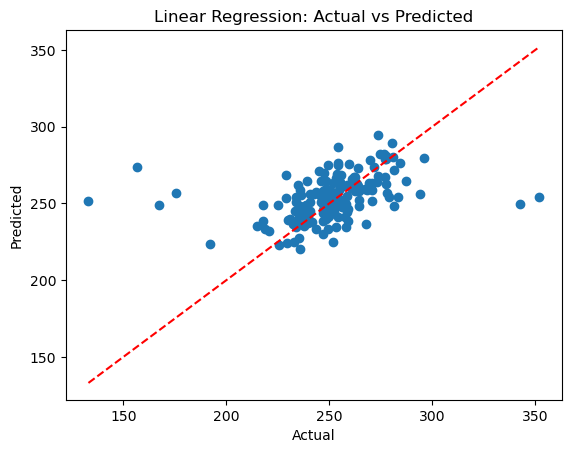

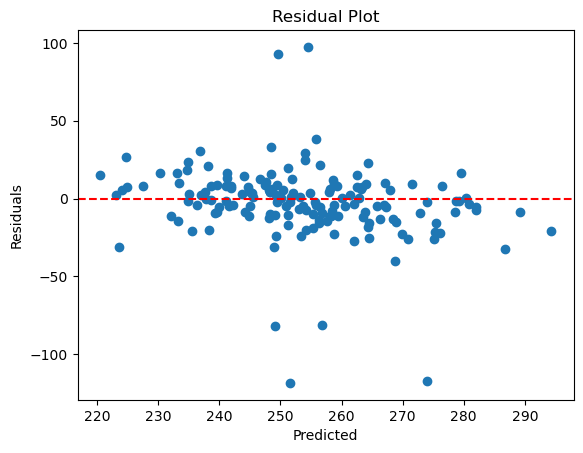

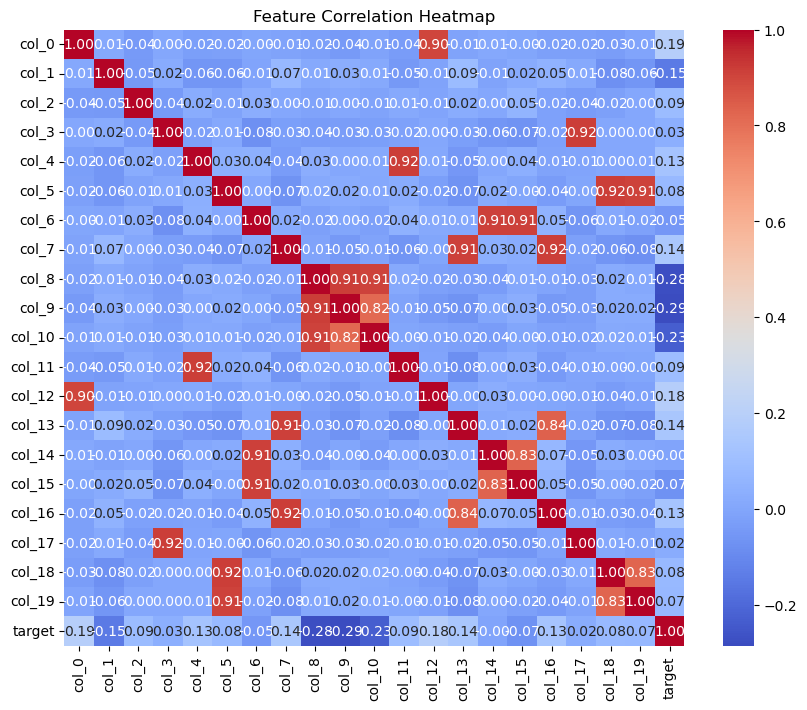

In [2]:
# Stock 5
# Load stock 5 training data
df = pd.read_csv('stock_5_train.csv')
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Features: {df.shape[1] - 1}, Target: 1")
df.head()

# summary statistics

df.describe().round(2)

# any missing values

print(df.isnull().sum())

# Which features correlate most with the target?
print(df.corr()['target'].sort_values(ascending=False))

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# 80/20 split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")

# Fit Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on validation set
lr_preds = lr_model.predict(X_val)

# Calculate RMSE
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_preds))
print(f"Linear Regression RMSE: {lr_rmse:.2f}")

# What coefficients did LR learn?
for name, coef in zip(X.columns, lr_model.coef_):
    print(f"{name}: {coef:>8.2f}")
print(f"Intercept: {lr_model.intercept_:.2f}")

#XGBOOST

# Fit XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,   # number of trees
    max_depth=3,         # how complex each tree is
    learning_rate=0.1,   # how much each tree contributes
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict on validation set
xgb_preds = xgb_model.predict(X_val)

# Calculate RMSE
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))
print(f"XGBoost RMSE: {xgb_rmse:.2f}")

print("=" * 40)
print("Model Comparison — Stock 5")
print("=" * 40)
print(f"Linear Regression RMSE: {lr_rmse:.2f}")
print(f"XGBoost RMSE:           {xgb_rmse:.2f}")
print()

if lr_rmse < xgb_rmse:
    print(">>> Linear Regression wins on this stock!")
    print("This suggests the relationship is mostly linear.")
    print("A fancier model isn't always better.")
else:
    print(">>> XGBoost wins on this stock!")
    print("There are non-linear patterns that LR can't capture.")

# Retrain on FULL training data
final_model = LinearRegression()  # using LR since it won on this stock
final_model.fit(X, y)

# Load the test set (just 1 row, no target)
test = pd.read_csv('stock_5_test.csv')
print(f"Test set shape: {test.shape}")
print(test)

# Predict!
prediction = final_model.predict(test)[0]
print(f"\nPredicted true value for Stock 5: £{prediction:.2f}")

print(f"Prediction: £{prediction:.2f}")
print(f"Model RMSE: £{lr_rmse:.2f}")
print()
print("Possible spread strategies:")
print(f"  Conservative (±2 RMSE): [{prediction - 2*lr_rmse:.2f}, {prediction + 2*lr_rmse:.2f}]  Spread = £{4*lr_rmse:.2f}")
print(f"  Moderate     (±1 RMSE): [{prediction - lr_rmse:.2f}, {prediction + lr_rmse:.2f}]  Spread = £{2*lr_rmse:.2f}")
print(f"  Aggressive (±0.5 RMSE): [{prediction - 0.5*lr_rmse:.2f}, {prediction + 0.5*lr_rmse:.2f}]  Spread = £{lr_rmse:.2f}")
print()
print("Tighter spread = more chance of becoming Market Maker = more risk!")

#Graphs

plt.scatter(y_val, lr_preds)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

residuals = y_val - lr_preds

plt.scatter(lr_preds, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()



TRAIN DATA OVERVIEW
Shape: (799, 21)
Rows: 799, Features: 20, Target: 1
      col_0     col_1     col_2     col_3     col_4     col_5     col_6  \
0 -0.863876  1.384891  0.361688  1.410418 -0.060149  0.511535  0.300228   
1 -0.489180 -0.216597  0.382571 -1.485321 -1.258863  0.001296  1.198746   
2  0.999336  0.097413  0.795778 -0.447158 -0.049559 -0.115499 -0.836057   
3  0.240389 -1.285496  0.955999 -2.445466 -0.586253  0.022930 -0.789762   
4 -0.760509 -0.560754 -0.022248 -1.562884  0.228770  0.967466  0.292934   

      col_7     col_8     col_9  ...    col_11    col_12    col_13    col_14  \
0 -0.624111 -0.144144 -0.113100  ... -0.178223 -0.450654  0.645839  0.114892   
1 -0.025397 -0.791660 -1.235792  ... -0.444204 -0.688237 -0.280983  1.078822   
2  0.662082  0.650249  0.337953  ...  0.241783  1.512476  0.652450 -0.642665   
3 -0.451756  1.839376  2.522597  ... -0.877818  0.385110 -0.782441 -0.876537   
4 -1.588898 -0.123809 -0.243013  ... -0.118053 -1.542348 -2.174826 -0.366245 

[HAMI-core Msg(2050:140367665663296:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(2048:139974142762304:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(2046:140399303589184:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(2045:140014056373568:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(2055:140695749950784:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(2047:139655214370112:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(2052:140464974609728:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(2054:140278743018816:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(2056:140039862897984:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(2043:140408997846336:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(2058:139624703307072:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(2049:140702450183488:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(2057:140027296456000:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(2053:139816100199744:libvgpu.c:839)]: Initializing.....
[HAMI-

XGBOOST
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 5, 'subsample': 0.8}
Best CV RMSE: 29.7891
Validation RMSE: 23.2341

RANDOM FOREST
Best Params: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best CV RMSE: 29.7933
Validation RMSE: 23.3083

5-FOLD CROSS-VALIDATION ON FULL DATA
Linear Regression    RMSE: 28.4767 (+/- 3.6595)
Ridge                RMSE: 27.9959 (+/- 3.6764)
Lasso                RMSE: 28.0898 (+/- 3.5431)
XGBoost              RMSE: 28.3107 (+/- 3.3197)
Random Forest        RMSE: 28.3968 (+/- 3.6370)

BEST MODEL SELECTION
Best model: Ridge
Best CV RMSE: 27.9959

TEST SET
Test set shape: (1, 43)
      col_0     col_1     col_2     col_3     col_4     col_5     col_6  \
0 -1.382738 -0.087927  0.296033  1.850463  0.085999 -2.334177 -0.093985   

      col_7     col_8     col_9  ...  col_13_squared  col_14_squared  \
0  2.739504  0.866366  0.151101  ..

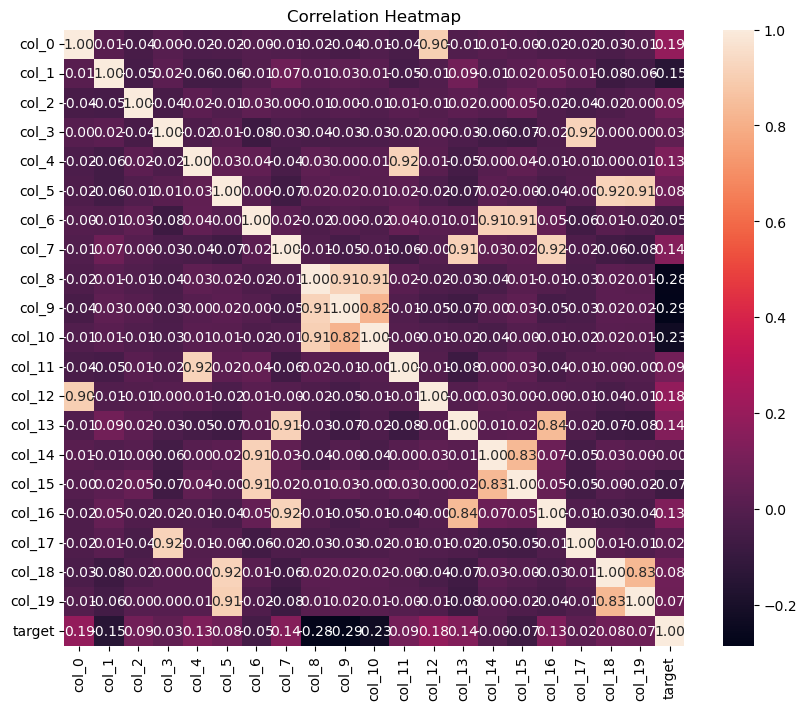

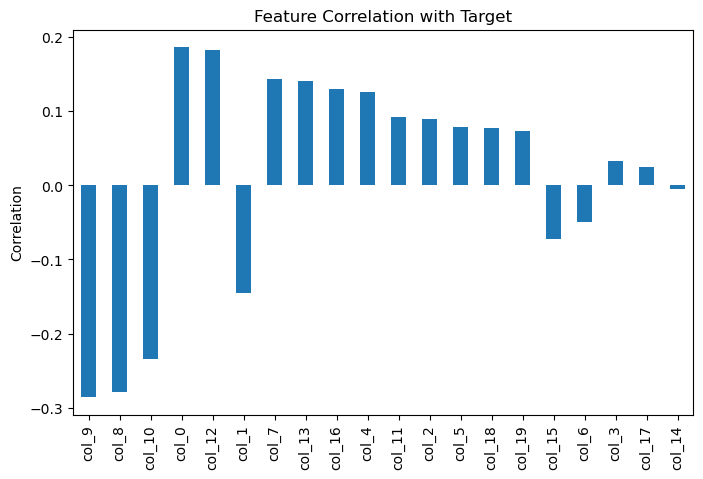

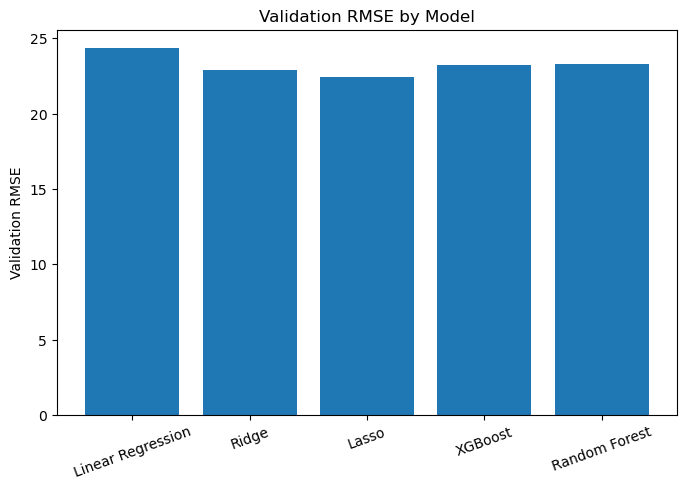

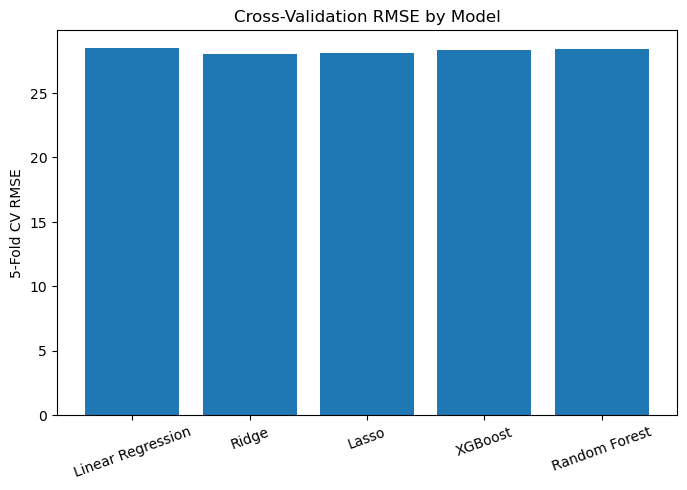

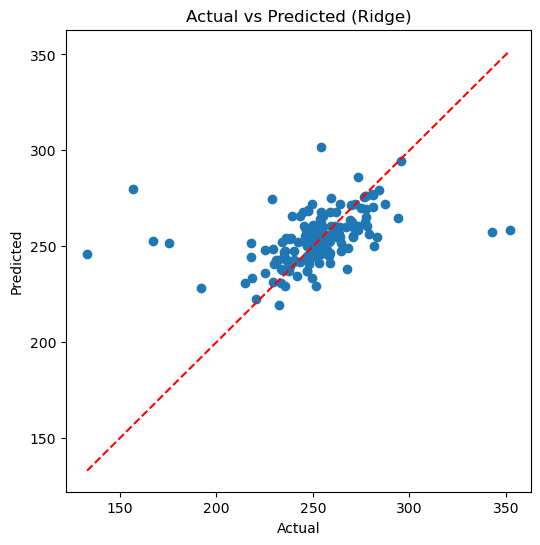

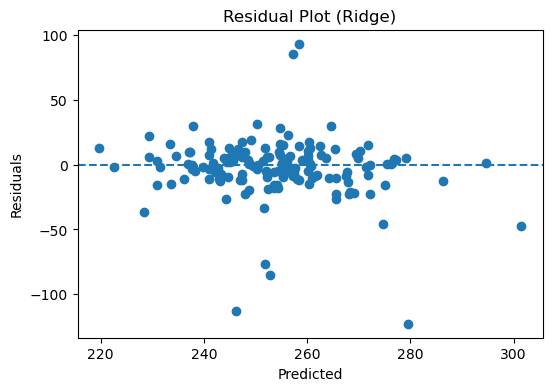

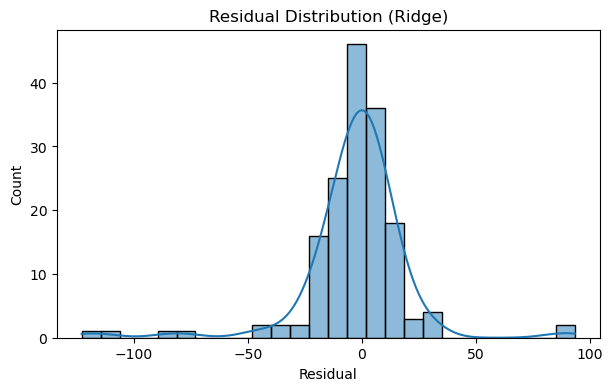

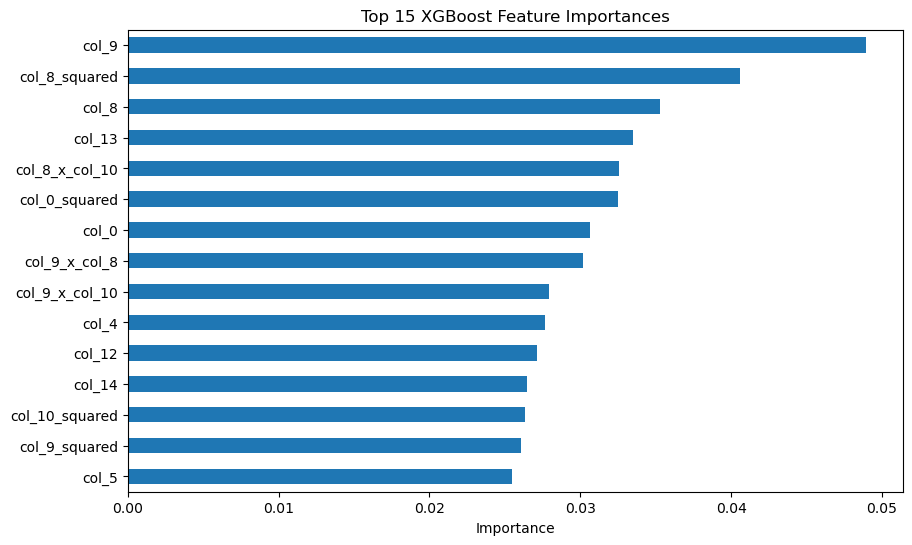

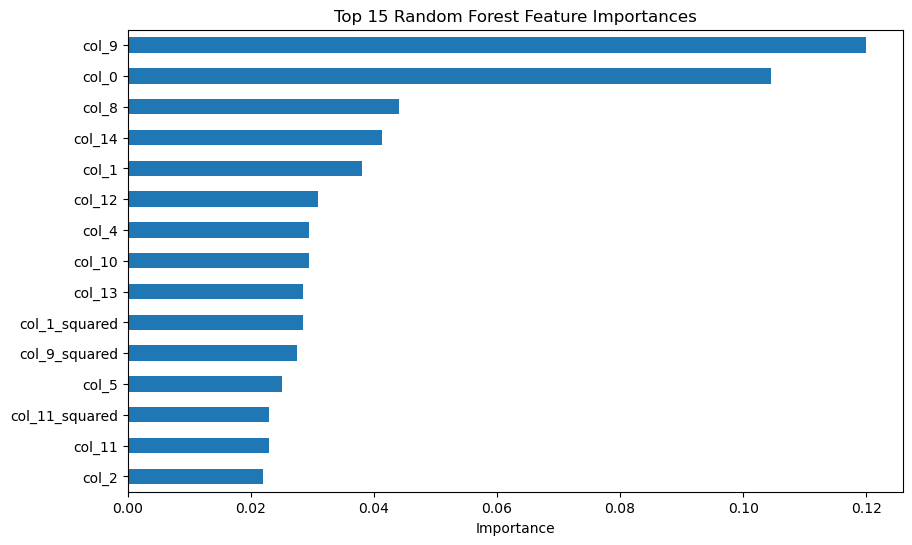

In [3]:
#Stock 5 (In Depth)
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

# 2
# 1. LOAD DATA
# 
df = pd.read_csv("stock_5_train.csv")

print("=" * 50)
print("TRAIN DATA OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Features: {df.shape[1] - 1}, Target: 1")
print(df.head())
print()

print("=" * 50)
print("SUMMARY STATISTICS")
print("=" * 50)
print(df.describe().round(2))
print()

print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print()

print("=" * 50)
print("CORRELATION WITH TARGET")
print("=" * 50)
print(df.corr(numeric_only=True)["target"].sort_values(ascending=False))
print()

# 
# 2. PREPARE FEATURES
# 
X = df.drop("target", axis=1).copy()
y = df["target"].copy()

# Optional simple feature engineering:
# Add squared versions of numeric columns
for col in X.columns:
    X[f"{col}_squared"] = X[col] ** 2

# Add interaction terms for top correlated original features
corr_with_target = df.corr(numeric_only=True)["target"].drop("target").abs().sort_values(ascending=False)
top_features = corr_with_target.head(min(3, len(corr_with_target))).index.tolist()

if len(top_features) >= 2:
    for i in range(len(top_features)):
        for j in range(i + 1, len(top_features)):
            f1, f2 = top_features[i], top_features[j]
            X[f"{f1}_x_{f2}"] = X[f1] * X[f2]

print("=" * 50)
print("FEATURES AFTER ENGINEERING")
print("=" * 50)
print(f"Total features: {X.shape[1]}")
print(X.head())
print()

# 
# 3. TRAIN / VALIDATION SPLIT
# 
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=" * 50)
print("TRAIN / VALIDATION SPLIT")
print("=" * 50)
print(f"Training set:   {X_train.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")
print()

# 
# 4. BASELINE LINEAR REGRESSION
# 
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_val)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_preds))

print("=" * 50)
print("BASELINE LINEAR REGRESSION")
print("=" * 50)
print(f"Validation RMSE: {lr_rmse:.4f}")
print()

# 
# 5. RIDGE TUNING
# 
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

ridge_param_grid = {
    "ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
ridge_preds = best_ridge.predict(X_val)
ridge_rmse = np.sqrt(mean_squared_error(y_val, ridge_preds))

print("=" * 50)
print("RIDGE REGRESSION")
print("=" * 50)
print("Best Params:", ridge_grid.best_params_)
print(f"Best CV RMSE: {-ridge_grid.best_score_:.4f}")
print(f"Validation RMSE: {ridge_rmse:.4f}")
print()

# 
# 6. LASSO TUNING
# 
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=10000))
])

lasso_param_grid = {
    "lasso__alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_
lasso_preds = best_lasso.predict(X_val)
lasso_rmse = np.sqrt(mean_squared_error(y_val, lasso_preds))

print("=" * 50)
print("LASSO REGRESSION")
print("=" * 50)
print("Best Params:", lasso_grid.best_params_)
print(f"Best CV RMSE: {-lasso_grid.best_score_:.4f}")
print(f"Validation RMSE: {lasso_rmse:.4f}")
print()

# 
# 7. XGBOOST TUNING
# 
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

xgb_param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.03, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
xgb_preds = best_xgb.predict(X_val)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))

print("=" * 50)
print("XGBOOST")
print("=" * 50)
print("Best Params:", xgb_grid.best_params_)
print(f"Best CV RMSE: {-xgb_grid.best_score_:.4f}")
print(f"Validation RMSE: {xgb_rmse:.4f}")
print()

# 
# 8. RANDOM FOREST (OPTIONAL)
# 
rf = RandomForestRegressor(random_state=42)

rf_param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
rf_preds = best_rf.predict(X_val)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_preds))

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print("Best Params:", rf_grid.best_params_)
print(f"Best CV RMSE: {-rf_grid.best_score_:.4f}")
print(f"Validation RMSE: {rf_rmse:.4f}")
print()

# 
# 9. CROSS-VALIDATION ON FULL DATA
# 
models = {
    "Linear Regression": lr_pipeline,
    "Ridge": best_ridge,
    "Lasso": best_lasso,
    "XGBoost": best_xgb,
    "Random Forest": best_rf
}

print("=" * 50)
print("5-FOLD CROSS-VALIDATION ON FULL DATA")
print("=" * 50)

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    rmse_mean = -scores.mean()
    rmse_std = scores.std()
    cv_results[name] = rmse_mean
    print(f"{name:<20} RMSE: {rmse_mean:.4f} (+/- {rmse_std:.4f})")

print()

# 
# 10. SELECT BEST MODEL
# 
best_model_name = min(cv_results, key=cv_results.get)
best_model = models[best_model_name]

print("=" * 50)
print("BEST MODEL SELECTION")
print("=" * 50)
print(f"Best model: {best_model_name}")
print(f"Best CV RMSE: {cv_results[best_model_name]:.4f}")
print()

# 
# 11. RETRAIN BEST MODEL ON FULL TRAINING DATA
# 
best_model.fit(X, y)

# 
# 12. LOAD TEST DATA
# 
test = pd.read_csv("stock_5_test.csv")

# Must apply same feature engineering to test set
for col in test.columns:
    test[f"{col}_squared"] = test[col] ** 2

if len(top_features) >= 2:
    for i in range(len(top_features)):
        for j in range(i + 1, len(top_features)):
            f1, f2 = top_features[i], top_features[j]
            test[f"{f1}_x_{f2}"] = test[f1] * test[f2]

# Make sure test columns match training columns
test = test.reindex(columns=X.columns, fill_value=0)

print("=" * 50)
print("TEST SET")
print("=" * 50)
print(f"Test set shape: {test.shape}")
print(test)
print()

# 
# 13. FINAL PREDICTION
# 
prediction = best_model.predict(test)[0]
best_rmse = cv_results[best_model_name]

print("=" * 50)
print("FINAL PREDICTION")
print("=" * 50)
print(f"Predicted true value for Stock 5: £{prediction:.2f}")
print(f"Chosen model: {best_model_name}")
print(f"Estimated RMSE: £{best_rmse:.2f}")
print()

print("Possible spread strategies:")
print(f"  Conservative (±2 RMSE): [{prediction - 2*best_rmse:.2f}, {prediction + 2*best_rmse:.2f}]  Spread = £{4*best_rmse:.2f}")
print(f"  Moderate     (±1 RMSE): [{prediction - best_rmse:.2f}, {prediction + best_rmse:.2f}]  Spread = £{2*best_rmse:.2f}")
print(f"  Aggressive (±0.5 RMSE): [{prediction - 0.5*best_rmse:.2f}, {prediction + 0.5*best_rmse:.2f}]  Spread = £{best_rmse:.2f}")
print()
print("Tighter spread = more chance of becoming Market Maker = more risk!")

# 1. Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 2. Feature correlation with target
corr_target = df.corr(numeric_only=True)["target"].drop("target").sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 5))
corr_target.plot(kind="bar")
plt.title("Feature Correlation with Target")
plt.ylabel("Correlation")
plt.show()

# 3. Validation RMSE by model
val_rmse_results = {
    "Linear Regression": lr_rmse,
    "Ridge": ridge_rmse,
    "Lasso": lasso_rmse,
    "XGBoost": xgb_rmse,
    "Random Forest": rf_rmse
}
plt.figure(figsize=(8, 5))
plt.bar(val_rmse_results.keys(), val_rmse_results.values())
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE by Model")
plt.xticks(rotation=20)
plt.show()

# 4. Cross-validation RMSE by model
plt.figure(figsize=(8, 5))
plt.bar(cv_results.keys(), cv_results.values())
plt.ylabel("5-Fold CV RMSE")
plt.title("Cross-Validation RMSE by Model")
plt.xticks(rotation=20)
plt.show()

# 5. Actual vs predicted for best model
plot_model = models[best_model_name]
plot_model.fit(X_train, y_train)
best_val_preds = plot_model.predict(X_val)

plt.figure(figsize=(6, 6))
plt.scatter(y_val, best_val_preds)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

# 6. Residual plot
residuals = y_val - best_val_preds
plt.figure(figsize=(6, 4))
plt.scatter(best_val_preds, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title(f"Residual Plot ({best_model_name})")
plt.show()

# 7. Residual distribution
plt.figure(figsize=(7, 4))
sns.histplot(residuals, kde=True)
plt.xlabel("Residual")
plt.title(f"Residual Distribution ({best_model_name})")
plt.show()

# 8. XGBoost feature importance
xgb_importance = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
xgb_importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 15 XGBoost Feature Importances")
plt.show()

# 9. Random Forest feature importance
rf_importance = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
rf_importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 15 Random Forest Feature Importances")
plt.show()

Shape: (119, 9)
Rows: 119, Features: 8, Target: 1
col_0     0
col_1     0
col_2     0
col_3     0
col_4     0
col_5     0
col_6     0
col_7     0
target    0
dtype: int64
target    1.000000
col_4     0.039756
col_5     0.031112
col_1    -0.037582
col_2    -0.064276
col_0    -0.074481
col_7    -0.093005
col_6    -0.164405
col_3    -0.246184
Name: target, dtype: float64
Training set: 95 rows
Validation set: 24 rows
Linear Regression RMSE: 70.76
col_0:     6.38
col_1:    -3.74
col_2:     1.51
col_3:   -17.07
col_4:     1.93
col_5:     0.92
col_6:     8.70
col_7:    -6.88
Intercept: 169.45
XGBoost RMSE: 96.48
Model Comparison — Stock 6
Linear Regression RMSE: 70.76
XGBoost RMSE:           96.48

>>> Linear Regression wins on this stock!
This suggests the relationship is mostly linear.
A fancier model isn't always better.
Test set shape: (1, 8)
      col_0     col_1     col_2     col_3    col_4     col_5     col_6  \
0 -0.812941 -0.415357 -0.612097 -0.140791  1.06598  0.157049  0.169878   


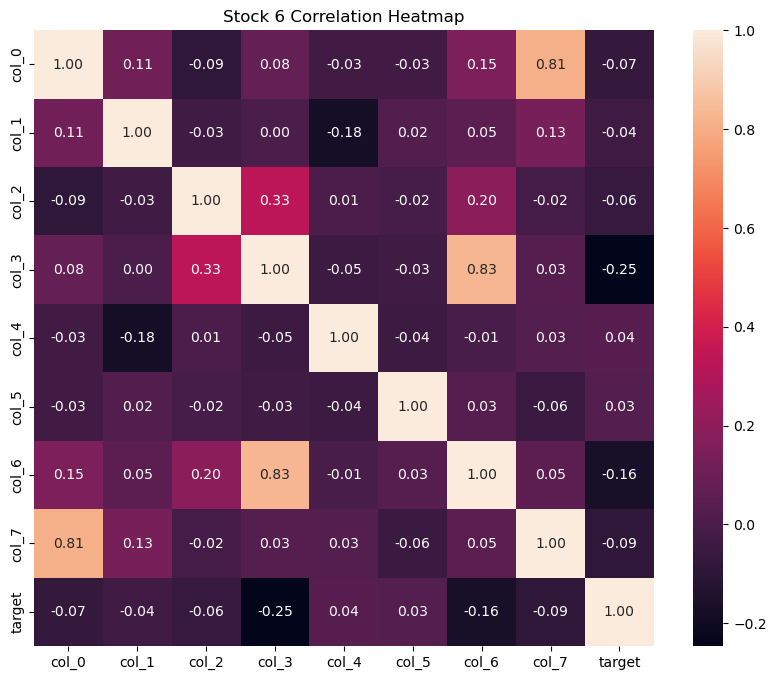

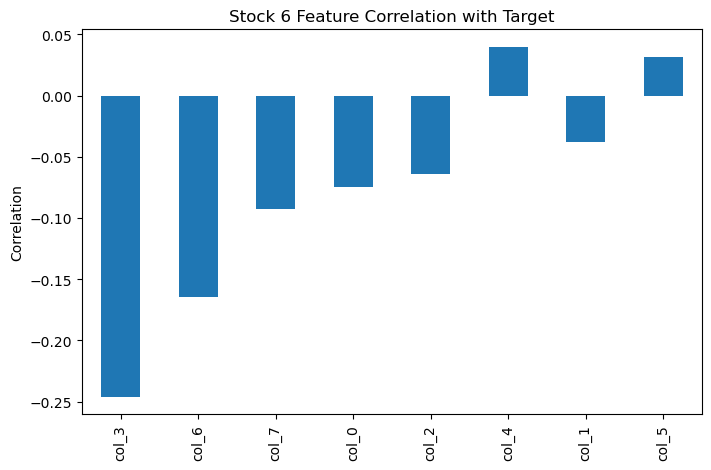

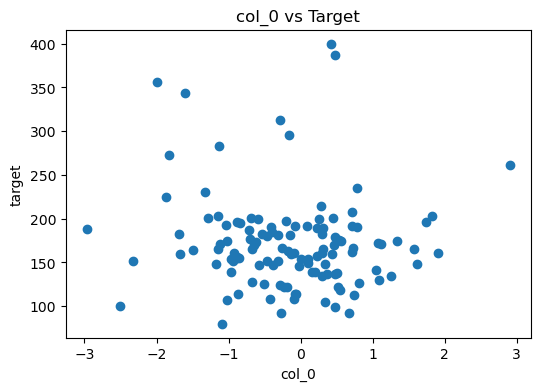

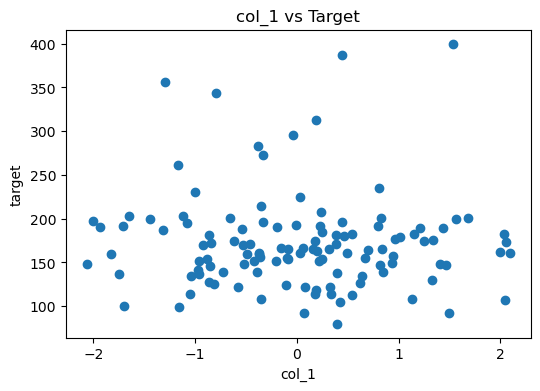

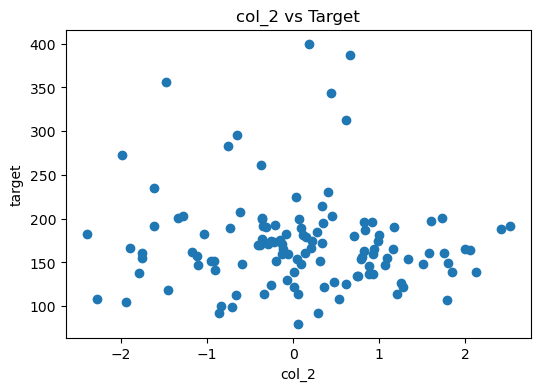

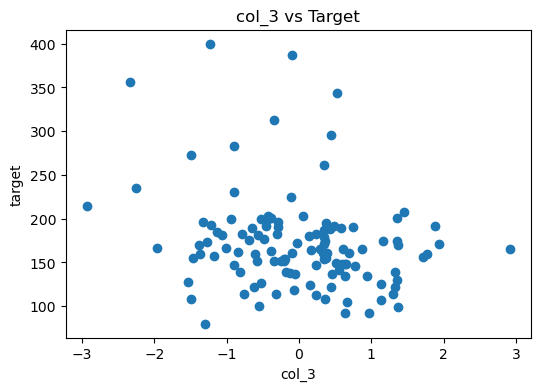

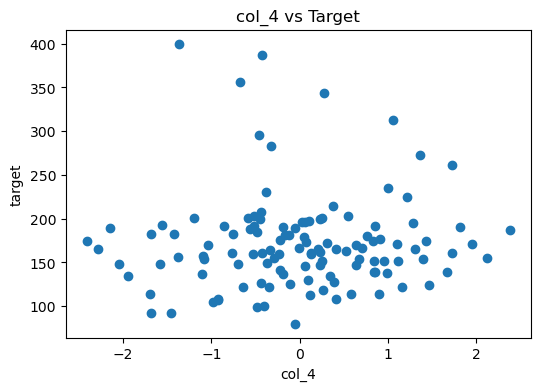

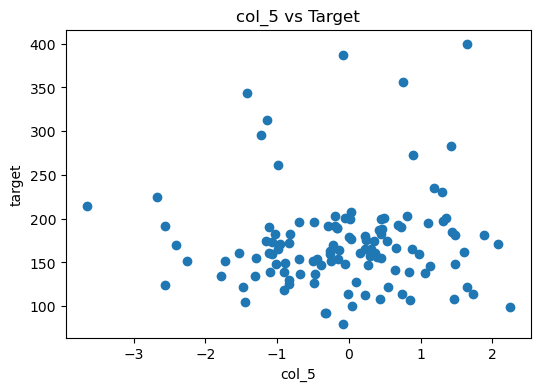

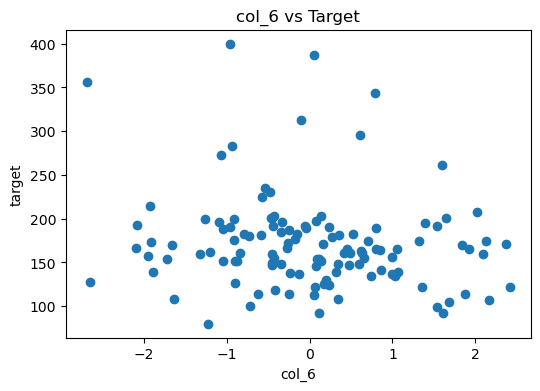

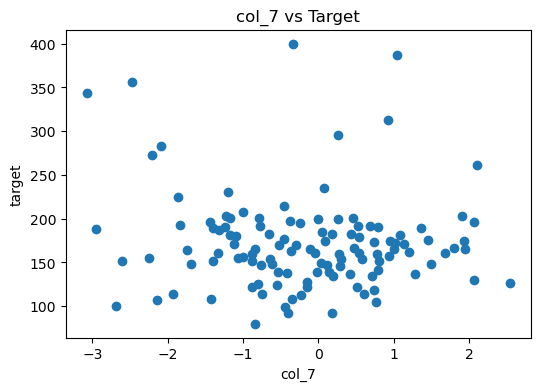

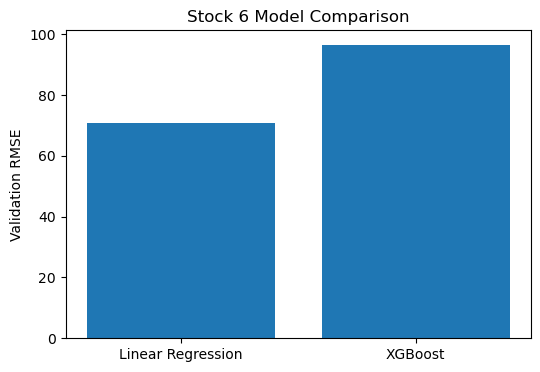

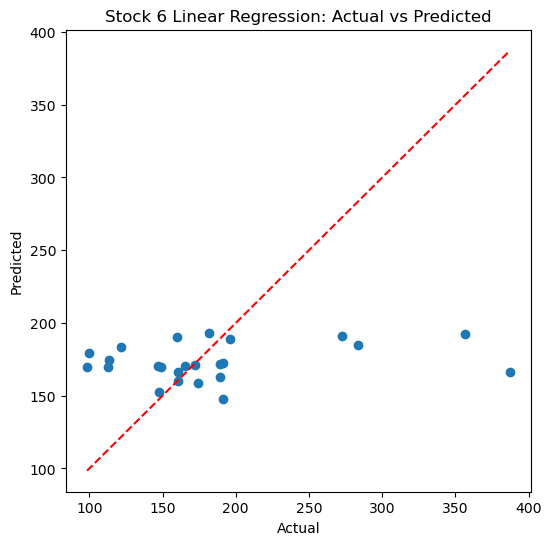

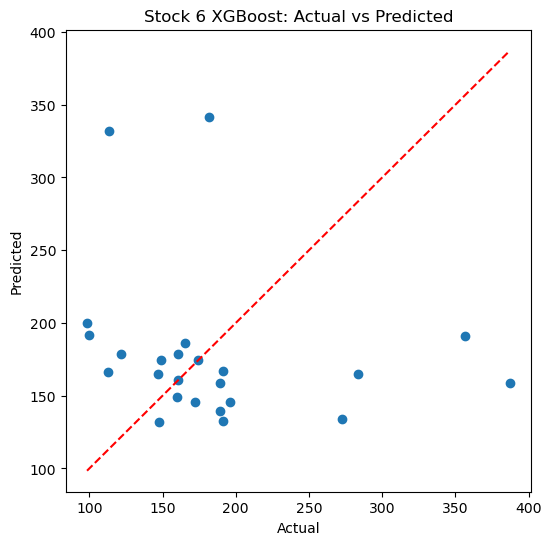

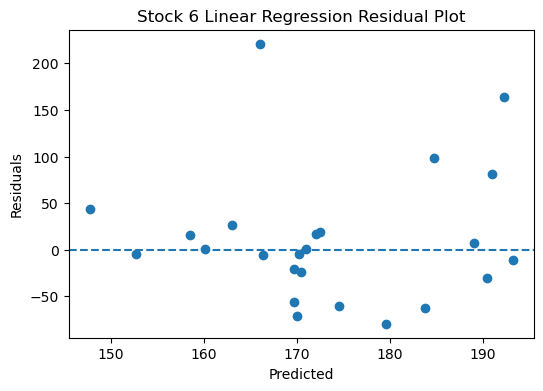

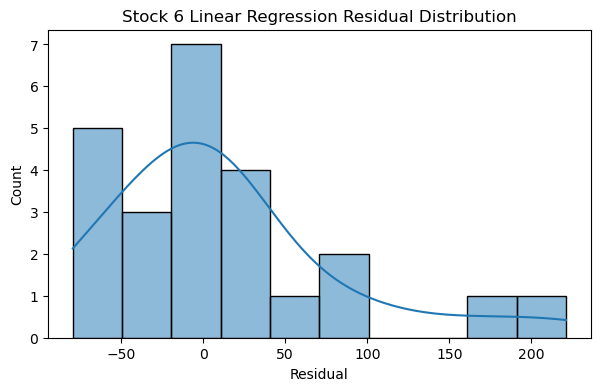

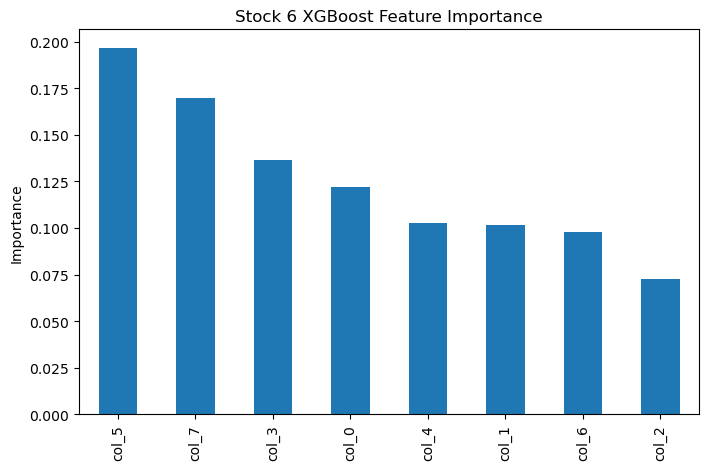

[HAMI-core Msg(2048:139974142762304:multiprocess_memory_limit.c:455)]: Calling exit handler 2048
[HAMI-core Msg(2049:140702450183488:multiprocess_memory_limit.c:455)]: Calling exit handler 2049
[HAMI-core Msg(2055:140695749950784:multiprocess_memory_limit.c:455)]: Calling exit handler 2055
[HAMI-core Msg(2056:140039862897984:multiprocess_memory_limit.c:455)]: Calling exit handler 2056
[HAMI-core Msg(2051:139804087561536:multiprocess_memory_limit.c:455)]: Calling exit handler 2051
[HAMI-core Msg(2057:140027296456000:multiprocess_memory_limit.c:455)]: Calling exit handler 2057
[HAMI-core Msg(2046:140399303589184:multiprocess_memory_limit.c:455)]: Calling exit handler 2046
[HAMI-core Msg(2052:140464974609728:multiprocess_memory_limit.c:455)]: Calling exit handler 2052
[HAMI-core Msg(2050:140367665663296:multiprocess_memory_limit.c:455)]: Calling exit handler 2050
[HAMI-core Msg(2053:139816100199744:multiprocess_memory_limit.c:455)]: Calling exit handler 2053
[HAMI-core Msg(2047:1396552143

In [4]:
#Stock 6

# Load stock 1 training data
df = pd.read_csv('stock_6_train.csv')
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Features: {df.shape[1] - 1}, Target: 1")
df.head()

# summary statistics

df.describe().round(2)

# any missing values

print(df.isnull().sum())

# Which features correlate most with the target?
print(df.corr()['target'].sort_values(ascending=False))

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# 80/20 split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")

# Fit Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on validation set
lr_preds = lr_model.predict(X_val)

# Calculate RMSE
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_preds))
print(f"Linear Regression RMSE: {lr_rmse:.2f}")

# What coefficients did LR learn?
for name, coef in zip(X.columns, lr_model.coef_):
    print(f"{name}: {coef:>8.2f}")
print(f"Intercept: {lr_model.intercept_:.2f}")

#XGBOOST

# Fit XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,   # number of trees
    max_depth=3,         # how complex each tree is
    learning_rate=0.1,   # how much each tree contributes
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict on validation set
xgb_preds = xgb_model.predict(X_val)

# Calculate RMSE
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))
print(f"XGBoost RMSE: {xgb_rmse:.2f}")

print("=" * 40)
print("Model Comparison — Stock 6")
print("=" * 40)
print(f"Linear Regression RMSE: {lr_rmse:.2f}")
print(f"XGBoost RMSE:           {xgb_rmse:.2f}")
print()

if lr_rmse < xgb_rmse:
    print(">>> Linear Regression wins on this stock!")
    print("This suggests the relationship is mostly linear.")
    print("A fancier model isn't always better.")
else:
    print(">>> XGBoost wins on this stock!")
    print("There are non-linear patterns that LR can't capture.")

# Retrain on FULL training data
final_model = LinearRegression()  # using LR since it won on this stock
final_model.fit(X, y)

# Load the test set (just 1 row, no target)
test = pd.read_csv('stock_6_test.csv')
print(f"Test set shape: {test.shape}")
print(test)

# Predict!
prediction = final_model.predict(test)[0]
print(f"\nPredicted true value for Stock 6: £{prediction:.2f}")

print(f"Prediction: £{prediction:.2f}")
print(f"Model RMSE: £{lr_rmse:.2f}")
print()
print("Possible spread strategies:")
print(f"  Conservative (±2 RMSE): [{prediction - 2*lr_rmse:.2f}, {prediction + 2*lr_rmse:.2f}]  Spread = £{4*lr_rmse:.2f}")
print(f"  Moderate     (±1 RMSE): [{prediction - lr_rmse:.2f}, {prediction + lr_rmse:.2f}]  Spread = £{2*lr_rmse:.2f}")
print(f"  Aggressive (±0.5 RMSE): [{prediction - 0.5*lr_rmse:.2f}, {prediction + 0.5*lr_rmse:.2f}]  Spread = £{lr_rmse:.2f}")
print()
print("Tighter spread = more chance of becoming Market Maker = more risk!")

#Graphs

# 1. Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Stock 6 Correlation Heatmap")
plt.show()

# 2. Feature correlation with target
corr_target = df.corr(numeric_only=True)["target"].drop("target").sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 5))
corr_target.plot(kind="bar")
plt.title("Stock 6 Feature Correlation with Target")
plt.ylabel("Correlation")
plt.show()

# 3. Feature vs target scatter plots
for col in X.columns:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[col], df["target"])
    plt.xlabel(col)
    plt.ylabel("target")
    plt.title(f"{col} vs Target")
    plt.show()

# 4. Model comparison
model_rmse = {
    "Linear Regression": lr_rmse,
    "XGBoost": xgb_rmse
}
plt.figure(figsize=(6, 4))
plt.bar(model_rmse.keys(), model_rmse.values())
plt.ylabel("Validation RMSE")
plt.title("Stock 6 Model Comparison")
plt.show()

# 5. Actual vs predicted - Linear Regression
plt.figure(figsize=(6, 6))
plt.scatter(y_val, lr_preds)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Stock 6 Linear Regression: Actual vs Predicted")
plt.show()

# 6. Actual vs predicted - XGBoost
plt.figure(figsize=(6, 6))
plt.scatter(y_val, xgb_preds)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Stock 6 XGBoost: Actual vs Predicted")
plt.show()

# 7. Residual plot - Linear Regression
lr_residuals = y_val - lr_preds
plt.figure(figsize=(6, 4))
plt.scatter(lr_preds, lr_residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Stock 6 Linear Regression Residual Plot")
plt.show()

# 8. Residual distribution - Linear Regression
plt.figure(figsize=(7, 4))
sns.histplot(lr_residuals, kde=True)
plt.xlabel("Residual")
plt.title("Stock 6 Linear Regression Residual Distribution")
plt.show()

# 9. XGBoost feature importance
importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importance.plot(kind="bar")
plt.ylabel("Importance")
plt.title("Stock 6 XGBoost Feature Importance")
plt.show()


Shape: (119, 9)
Rows: 119, Features: 8, Target: 1

First 5 rows:
      col_0     col_1     col_2     col_3     col_4     col_5     col_6  \
0 -0.570944  0.813764  1.068472  0.232878  0.234401  0.270343  0.471025   
1 -0.205162 -2.003522  1.604254 -0.457699  0.107880  1.309551  0.071674   
2 -0.512243 -0.813773  0.615979  1.128972 -0.113947 -0.840156  0.173653   
3 -0.189244  0.328662  0.361922  1.320662 -0.342786 -1.476858  1.357183   
4 -0.878152 -0.334123  0.915903 -1.326393  0.030631 -0.484169 -1.094665   

      col_7      target  
0 -0.760052  146.787077  
1 -0.375889  196.708960  
2 -0.798076  125.201647  
3 -0.146051  122.023737  
4 -1.434372  195.946833  

Summary statistics:
        col_0   col_1   col_2   col_3   col_4   col_5   col_6   col_7  target
count  119.00  119.00  119.00  119.00  119.00  119.00  119.00  119.00  119.00
mean    -0.16    0.02    0.10   -0.02   -0.01   -0.09    0.00   -0.17  172.24
std      0.96    0.98    1.06    0.98    1.00    1.09    1.11    1.19   5

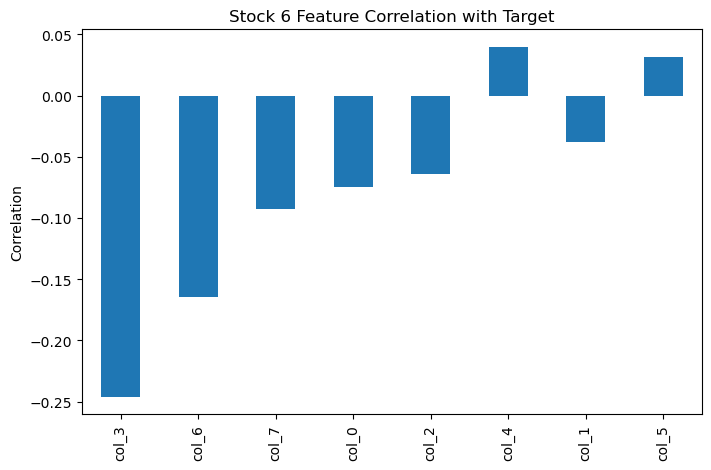

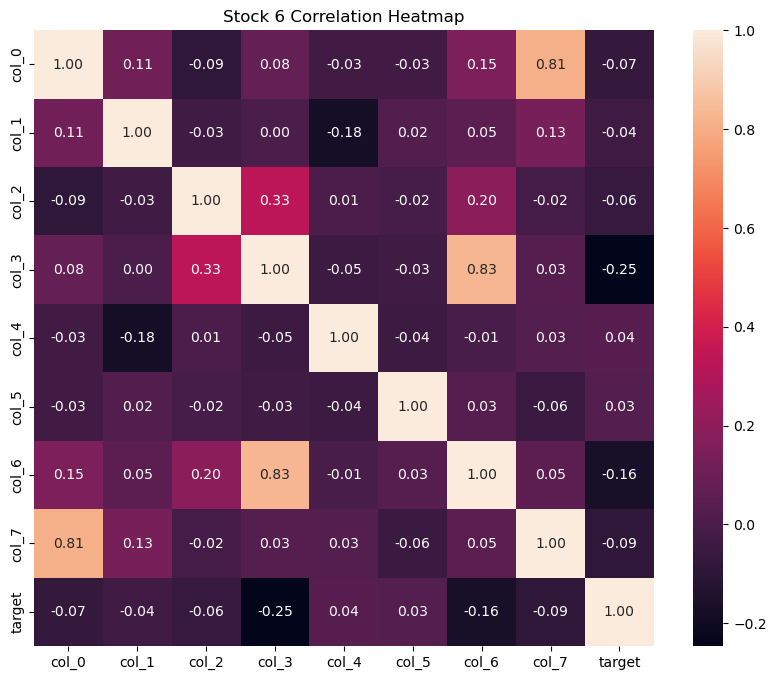

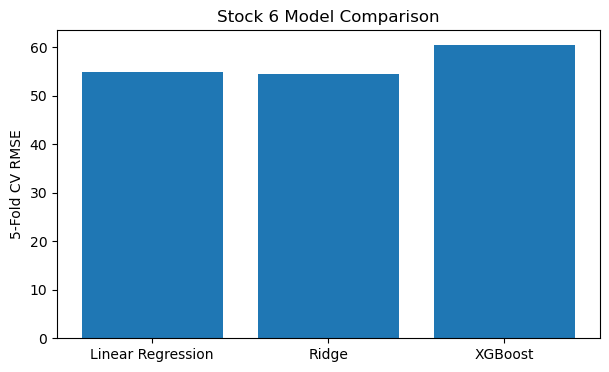

NameError: name 'cross_val_predict' is not defined

In [5]:
#Stock 6 In Depth

import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

# 
# LOAD DATA
# 
df = pd.read_csv("stock_6_train.csv")

print("Shape:", df.shape)
print(f"Rows: {df.shape[0]}, Features: {df.shape[1] - 1}, Target: 1")
print("\nFirst 5 rows:")
print(df.head())

print("\nSummary statistics:")
print(df.describe().round(2))

print("\nMissing values:")
print(df.isnull().sum())

print("\nFeature correlations with target:")
print(df.corr(numeric_only=True)["target"].sort_values(ascending=False))

# 
# FEATURE ENGINEERING
# 
def add_features(data):
    data = data.copy()

    feature_cols = [c for c in data.columns if c != "target"]

    # Add a few general nonlinear / interaction features
    # Only create them if enough columns exist
    if len(feature_cols) >= 2:
        data["f0_x_f1"] = data[feature_cols[0]] * data[feature_cols[1]]

    if len(feature_cols) >= 4:
        data["f2_x_f3"] = data[feature_cols[2]] * data[feature_cols[3]]

    if len(feature_cols) >= 1:
        data["f0_sq"] = data[feature_cols[0]] ** 2
        data["f0_abs"] = np.abs(data[feature_cols[0]])

    if len(feature_cols) >= 2:
        data["f1_sq"] = data[feature_cols[1]] ** 2
        data["f1_abs"] = np.abs(data[feature_cols[1]])

    if len(feature_cols) >= 3:
        data["f2_sq"] = data[feature_cols[2]] ** 2

    return data

df_fe = add_features(df)

# Separate features and target
X = df_fe.drop("target", axis=1)
y = df_fe["target"]

print("\nFeature set after engineering:", X.shape)

# 
# CROSS-VALIDATION SETUP
# 
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 
# MODEL 1: LINEAR REGRESSION
# 
lr_model = LinearRegression()

lr_scores = cross_val_score(
    lr_model,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=cv
)

lr_rmse = -lr_scores.mean()
print(f"\nLinear Regression CV RMSE: {lr_rmse:.4f}")

# 
# MODEL 2: RIDGE REGRESSION
# 
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_scores = cross_val_score(
    ridge_model,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=cv
)

ridge_rmse = -ridge_scores.mean()
print(f"Ridge CV RMSE: {ridge_rmse:.4f}")

# 
# MODEL 3: XGBOOST
# 
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42
)

xgb_scores = cross_val_score(
    xgb_model,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=cv
)

xgb_rmse = -xgb_scores.mean()
print(f"XGBoost CV RMSE: {xgb_rmse:.4f}")

# 
# COMPARE MODELS
# 
results = {
    "Linear Regression": lr_rmse,
    "Ridge": ridge_rmse,
    "XGBoost": xgb_rmse
}

best_model_name = min(results, key=results.get)
best_rmse = results[best_model_name]

print("\n" + "=" * 40)
print("MODEL COMPARISON — STOCK 6")
print("=" * 40)
for model_name, rmse in results.items():
    print(f"{model_name:<18}: {rmse:.4f}")

print(f"\nBest model: {best_model_name}")
print(f"Best CV RMSE: {best_rmse:.4f}")

# 
# FIT BEST MODEL ON FULL DATA
# 
if best_model_name == "Linear Regression":
    final_model = LinearRegression()
elif best_model_name == "Ridge":
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])
else:
    final_model = XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42
    )

final_model.fit(X, y)

# 
# LOAD TEST DATA
# 
test = pd.read_csv("stock_6_test.csv")
test_fe = add_features(test)

print("\nTest set shape:", test_fe.shape)
print(test_fe)

# 
# PREDICT TEST Value
# 
prediction = final_model.predict(test_fe)[0]

print(f"\nPredicted true value for Stock 6: £{prediction:.2f}")
print(f"Best model used: {best_model_name}")
print(f"Model CV RMSE: £{best_rmse:.2f}")

print("\nPossible spread strategies:")
print(f"Conservative (±2 RMSE): [{prediction - 2*best_rmse:.2f}, {prediction + 2*best_rmse:.2f}]  Spread = £{4*best_rmse:.2f}")
print(f"Moderate     (±1 RMSE): [{prediction - best_rmse:.2f}, {prediction + best_rmse:.2f}]  Spread = £{2*best_rmse:.2f}")
print(f"Aggressive (±0.5 RMSE): [{prediction - 0.5*best_rmse:.2f}, {prediction + 0.5*best_rmse:.2f}]  Spread = £{best_rmse:.2f}")

print("\nTighter spread = more chance of becoming Market Maker = more risk!")

#Graphs:

# 1. Feature correlation with target
corr_target = df.corr(numeric_only=True)["target"].drop("target").sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 5))
corr_target.plot(kind="bar")
plt.title("Stock 6 Feature Correlation with Target")
plt.ylabel("Correlation")
plt.show()

# 2. Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Stock 6 Correlation Heatmap")
plt.show()

# 3. Model comparison
plt.figure(figsize=(7, 4))
plt.bar(results.keys(), results.values())
plt.ylabel("5-Fold CV RMSE")
plt.title("Stock 6 Model Comparison")
plt.show()

# 4. Rebuild best model for CV predictions
if best_model_name == "Linear Regression":
    plot_model = LinearRegression()
elif best_model_name == "Ridge":
    plot_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])
else:
    plot_model = XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42
    )

cv_preds = cross_val_predict(plot_model, X, y, cv=cv)

# 5. Actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y, cv_preds)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

# 6. Residual plot
residuals = y - cv_preds
plt.figure(figsize=(6, 4))
plt.scatter(cv_preds, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title(f"Residual Plot ({best_model_name})")
plt.show()

# 7. Residual distribution
plt.figure(figsize=(7, 4))
sns.histplot(residuals, kde=True)
plt.xlabel("Residual")
plt.title(f"Residual Distribution ({best_model_name})")
plt.show()

# 8. XGBoost feature importance
xgb_model.fit(X, y)
importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 15 XGBoost Feature Importances")
plt.show()
